In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.activations import sigmoid
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt

In [ ]:
def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))

    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1,1))

In [ ]:
X,Y = load_coffee_data();
print(X.shape, Y.shape)

(200, 2) (200, 1)


In [ ]:
plt_y = Y.ravel()

In [ ]:
good = plt_y == 1
bad = plt_y == 0

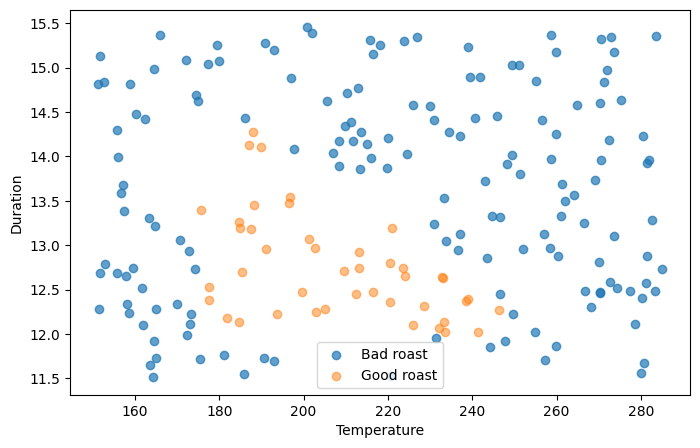

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(X[bad, 0], X[bad, 1], label="Bad roast", alpha=0.7)
plt.scatter(X[good, 0], X[good, 1], label="Good roast", alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Duration")
plt.legend()
plt.show()

In [ ]:
good.shape

(200, 1)

In [ ]:
norm_l = tf.keras.layers.Normalization(axis=-1)


In [ ]:
norm_l.adapt(X)
xn = norm_l(X)

xt = np.tile(xn, (1000,1))
yt = np.tile(Y,(1000,1))

In [ ]:
print(f"Temperature before normalization, max:{np.max(X, axis=0)[0]}, min:{np.min(X, axis=0)[0]}")

Temperature before normalization, max:284.99434167453603, min:151.32372212128612


In [ ]:
print(f"Duration before normalization, max:{np.max(X, axis=0)[1]} min:{np.min(X, axis=0)[1]}")

Duration before normalization, max:15.454206928801511 min:11.512747082472469


In [ ]:
print(f"Temperature before normalization, max:{np.max(xn, axis=0)[0]}, min:{np.min(xn, axis=0)[0]}")

Temperature before normalization, max:1.6597541570663452, min:-1.6852184534072876


In [ ]:
print(f"Duration before normalization, max:{np.max(xn, axis=0)[1]} min:{np.min(xn, axis=0)[1]}")

Duration before normalization, max:1.793238878250122 min:-1.6996712684631348


Layer implemented manually in a linear sequenc.

In [ ]:
layer1 = Dense(units=3, activation=sigmoid)
layer2 = Dense(units=1, activation=sigmoid)

In [ ]:
a = layer1(xn)
b = layer2(a)

using sequential to define layers

In [ ]:
model = Sequential ([
    Dense(units=3, activation=sigmoid, name="hl1"),
    Dense(units=1, activation=sigmoid, name="ol1")
])

In [ ]:
model.compile(
    loss = BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
)

model.fit(
    xt,yt, epochs=10
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.1997
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.1376
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.1308
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.1217
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.1119
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.0378
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0150
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0100
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0071
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.0051


In [ ]:
print(model.get_layer("hl1").get_weights())
print(model.get_layer("ol1").get_weights())

[array([[-16.81767   ,   0.09396259, -10.096486  ],
       [-14.154281  ,  -8.079701  ,  -0.19663823]], dtype=float32), array([ -2.3662796, -10.109541 , -11.134109 ], dtype=float32)]
[array([[ 28.431715],
       [-35.128246],
       [-39.63529 ]], dtype=float32), array([-8.472781], dtype=float32)]


In [ ]:
X_test = np.array([
    [200,13.9],  # positive example
    [200,17]])   # negative example
X_testn = norm_l(X_test)
predictions = model.predict(xn)
print("predictions = \n", predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
predictions = 
 [[1.00000000e+00]
 [2.83253115e-10]
 [2.09034071e-04]
 [1.32906762e-14]
 [9.99999821e-01]
 [9.99282539e-01]
 [2.11218896e-04]
 [2.48549535e-04]
 [2.09037680e-04]
 [9.99999464e-01]
 [1.00000000e+00]
 [2.09038873e-04]
 [1.57936040e-04]
 [2.08779733e-04]
 [3.94190605e-18]
 [3.98583477e-09]
 [2.09038684e-04]
 [2.17778521e-04]
 [2.10314975e-04]
 [2.07847610e-04]
 [2.09030899e-04]
 [2.08826124e-04]
 [2.11500825e-04]
 [1.00000000e+00]
 [1.34104562e-22]
 [2.08401616e-04]
 [2.09038873e-04]
 [2.03310818e-04]
 [2.09033082e-04]
 [9.99999821e-01]
 [1.22183883e-05]
 [1.12742387e-01]
 [3.43499562e-09]
 [2.49724419e-08]
 [2.10578248e-04]
 [2.08935671e-04]
 [2.09015561e-04]
 [2.09231293e-04]
 [1.97680856e-05]
 [2.08999409e-04]
 [2.94668268e-09]
 [2.09038873e-04]
 [2.47069187e-09]
 [3.26196670e-09]
 [1.40730917e-21]
 [2.08045254e-04]
 [4.41784960e-06]
 [1.00000000e+00]
 [7.05230264e-07]
 [5.23244069e-07]
 [1.00000000e+00]
 [9.99999583e-01]
 [2.090388

In [ ]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
# print(f"decisions = \n{yhat}")

In [ ]:
predictions = yhat.ravel()
predictions

array([1., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
       1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0.], dtype=float32)

In [ ]:
p_good = predictions == 1
p_bad = predictions ==0
print(type(xn))

<class 'numpy.ndarray'>


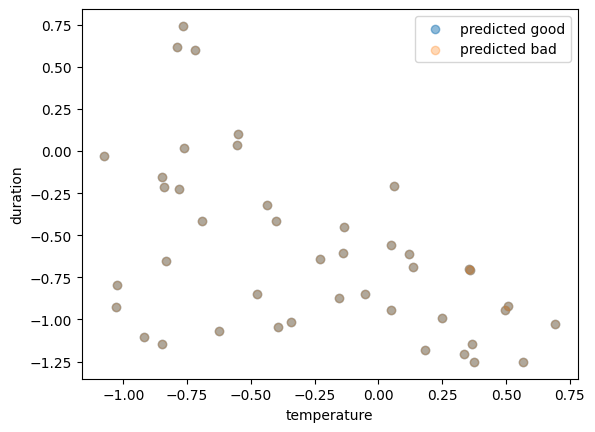

In [ ]:
plt.scatter(xn[p_good,0], xn[p_good,1], alpha=0.5, label="predicted good")
plt.scatter(xn[good, 0], xn[good, 1], alpha=0.3, label="predicted bad")
plt.xlabel("temperature")
plt.ylabel("duration")
plt.legend()
plt.show()

In [ ]:
xn.shape

(200, 2)